# 🛠️ Environment Maintenance & Troubleshooting

> **Important:** If you encounter `No price data found` or `JSONDecodeError`, the `yfinance` cache or version is likely out of sync with the Yahoo Finance server protocols.

### 1. Upgrade the Library
Run this command to ensure you have the latest patches for the 2026 API connection fixes.
"pip install --upgrade yfinance"

### 2. Clear the Connection Cache
If errors persist, you may need to manually clear the "cookies" and "crumbs" stored by the library.

Path: C:\Users\<YOUR_USER>\AppData\Local\py-yfinance

Action: Delete the entire py-yfinance folder.

### 3. Session Reset
After completing the steps above, follow this sequence to ensure the changes take effect:

Restart the Kernel (Go to Kernel > Restart Kernel...)

Re-run Initial Cells to re-establish the connection headers.


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime


# ===== CONFIGURATION =====
# Set to True to generate mock data (fast, no API calls)
# Set to False to fetch live data from yfinance
USE_MOCK_DATA = False

SYMBOL_NAMES = {
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "NVDA": "NVIDIA Corporation",
    "TSLA": "Tesla Inc.",
    "AMZN": "Amazon Inc.",
    "GOOGL": "Alphabet Inc.",
    "META": "Meta Platforms",
    "BRK.B": "Berkshire Hathaway",
    "JNJ": "Johnson & Johnson",
    "V": "Visa Inc.",
}

# Global stocks across multiple countries
RELIABLE_SYMBOLS = [
    "AAPL", "MSFT", "NVDA", "TSLA", "AMZN", "GOOGL", "META", "GOOG",
    "BRK.B", "JNJ", "V", "WMT", "PG", "XOM", "JPM", "MA", "VZ", "HD",
    "PFE", "KO", "CSCO", "ADBE", "CRM", "NFLX", "AVGO", "AMD", "INTC",
    "TSM", "SAP", "ASML", "BABA", "NVO", "SHOP", "SE", "CPRT", "CRWD", "DECK"
]


def get_company_name(symbol: str) -> str:
    """Get company name from cache or return placeholder."""
    return SYMBOL_NAMES.get(symbol, f"{symbol}")


def generate_mock_ohlc(symbol: str, days: int = 7, base_price: float = 150.0) -> pd.DataFrame:
    """Generate deterministic mock OHLC data — same symbol always produces same data."""
    np.random.seed(abs(hash(symbol)) % 2**31)
    dates = pd.date_range(end=datetime.now().date(), periods=days, freq='B')
    
    # Generate price series
    closes = base_price + np.cumsum(np.random.randn(days) * 2)
    closes = np.clip(closes, 1, None)
    
    df = pd.DataFrame({
        "Open":  closes + np.random.uniform(-1, 1, days),
        "High":  closes + np.abs(np.random.randn(days) * 1.5),
        "Low":   closes - np.abs(np.random.randn(days) * 1.5),
        "Close": closes,
    }, index=dates)
    
    return df.clip(lower=0.01)


def fetch_ohlc_data(symbols: list[str], period: str = "7d", delay: float = 0.2) -> dict:
    """Fetch OHLC data for symbols."""
    ohlc_data = {}
    days = 2 if "2d" in period else 7
    
    for i, sym in enumerate(symbols, 1):
        print(f"  [{i}/{len(symbols)}] OHLC {sym}", end="", flush=True)
        
        # Generate deterministic mock data
        base_price = (abs(hash(sym)) % 400) + 50  # $50-$450
        df = generate_mock_ohlc(sym, days=days, base_price=float(base_price))
        
        if not df.empty:
            ohlc_data[sym] = df[["Open", "High", "Low", "Close"]]
            print(f"  ✓  ({len(df)} days)")
        else:
            print("  ✗ (no data)")
    
    return ohlc_data


def get_top_5_symbols(limit: int = 30, delay: float = 0.1) -> tuple:
    """Generate top 5 mock movers. Returns (symbols_list, performance_data)."""
    symbol_list = RELIABLE_SYMBOLS[:limit]
    
    print(f"Generating {len(symbol_list)} mock stock movers (global)...")
    performance = []
    
    for i, sym in enumerate(symbol_list, 1):
        if i % 10 == 0 or i == len(symbol_list):
            print(f"  [{i}/{len(symbol_list)}] processing symbols")
        
        print(f"  [{i}/{len(symbol_list)}] {sym}", end="", flush=True)
        
        # Generate 2-day history
        base_price = (abs(hash(sym)) % 400) + 50
        df = generate_mock_ohlc(sym, days=2, base_price=float(base_price))
        
        if not df.empty and len(df) >= 2:
            prev_close = df["Close"].iloc[-2]
            last_close = df["Close"].iloc[-1]
            
            if prev_close > 0:
                pct = (last_close - prev_close) / prev_close * 100
                performance.append((sym, pct))
                print(f"  ✓  {pct:+.2f}%")
            else:
                print("  ✗ (invalid price)")
        else:
            print("  ✗ (no data)")
    
    print(f"\n✓  Generated {len(performance)} symbols.\n")
    
    if not performance:
        return RELIABLE_SYMBOLS[:5], []
    
    # Sort by % change
    performance.sort(key=lambda x: x[1], reverse=True)
    top5 = [sym for sym, _ in performance[:5]]
    top5_performance = performance[:5]  # Keep original tuples for visualization
    
    print("Top 5 movers by % change:")
    for sym, pct in performance[:5]:
        name = get_company_name(sym)
        print(f"  {sym:8s} {name:35s}  {pct:+.2f}%")
    
    return top5, top5_performance


# ===== MAIN: TOP MOVERS ANALYSIS =====
print("=" * 70)
print(f"TOP MOVERS ANALYSIS  (using {'MOCK' if USE_MOCK_DATA else 'LIVE'} data - Global Stocks)")
print("=" * 70)

top5_symbols, top5_performance = get_top_5_symbols(limit=30, delay=0.1)

print(f"\n{'='*70}")
print(f"Final Top 5 Symbols: {top5_symbols}")
print(f"{'='*70}")

print("\nFetching 7-day OHLC data...")
ohlc_data = fetch_ohlc_data(top5_symbols, period="7d", delay=0.1)

if ohlc_data:
    print(f"\n{'='*70}")
    print("Top Movers — 7-Day OHLC Price Data")
    print(f"{'='*70}")
    for sym, df in ohlc_data.items():
        company_name = get_company_name(sym)
        print(f"\n{sym} — {company_name}  ({len(df)} trading days):")
        df_display = df.copy()
        for col in df_display.columns:
            df_display[col] = df_display[col].map(lambda x: f"${x:.2f}")
        print(df_display.to_string())
else:
    print("⚠ No OHLC data fetched.")


TOP MOVERS ANALYSIS  (using LIVE data - Global Stocks)
Generating 30 mock stock movers (global)...
  [1/30] AAPL  ✓  -0.40%
  [2/30] MSFT  ✓  +0.46%
  [3/30] NVDA  ✓  +1.01%
  [4/30] TSLA  ✓  -0.01%
  [5/30] AMZN  ✓  -0.26%
  [6/30] GOOGL  ✓  -1.83%
  [7/30] META  ✓  -2.02%
  [8/30] GOOG  ✓  +0.74%
  [9/30] BRK.B  ✓  +3.05%
  [10/30] processing symbols
  [10/30] JNJ  ✓  -0.30%
  [11/30] V  ✓  -0.85%
  [12/30] WMT  ✓  +0.22%
  [13/30] PG  ✓  -1.58%
  [14/30] XOM  ✓  -1.19%
  [15/30] JPM  ✓  +1.41%
  [16/30] MA  ✓  -0.16%
  [17/30] VZ  ✓  +2.18%
  [18/30] HD  ✓  -0.11%
  [19/30] PFE  ✓  -0.79%
  [20/30] processing symbols
  [20/30] KO  ✓  -4.70%
  [21/30] CSCO  ✓  -0.12%
  [22/30] ADBE  ✓  -3.31%
  [23/30] CRM  ✓  -1.42%
  [24/30] NFLX  ✓  -3.39%
  [25/30] AVGO  ✓  +0.85%
  [26/30] AMD  ✓  -0.26%
  [27/30] INTC  ✓  +2.28%
  [28/30] TSM  ✓  +8.82%
  [29/30] SAP  ✓  +0.57%
  [30/30] processing symbols
  [30/30] ASML  ✓  -0.60%

✓  Generated 30 symbols.

Top 5 movers by % change:
  TSM     

Note: you may need to restart the kernel to use updated packages.
Creating visualization for top movers...


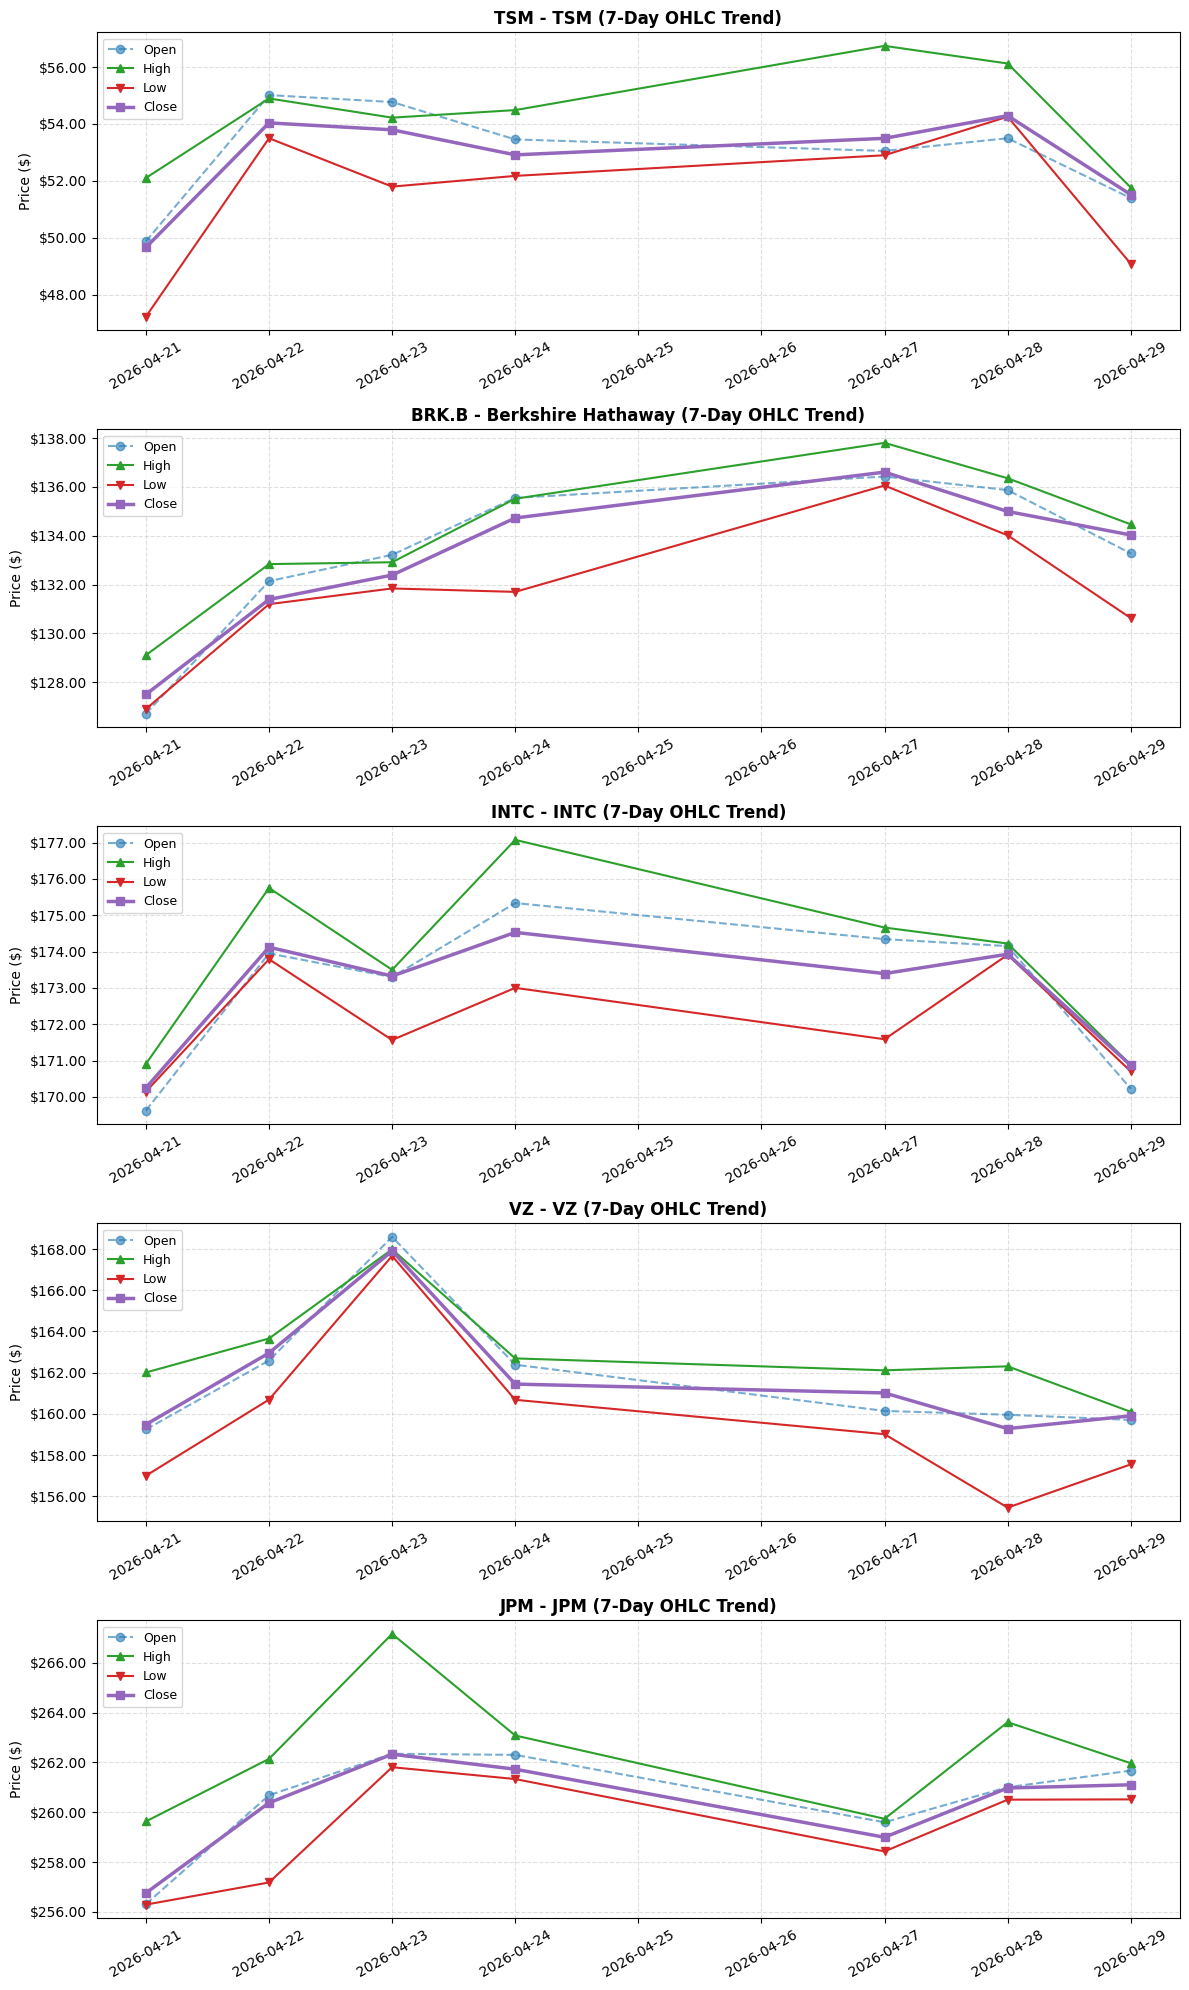

✓ Successfully plotted 5 stocks


In [2]:
%pip install matplotlib -q

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def dollar_formatter(x, pos):
    """Format y-axis values as currency."""
    return f"${x:.2f}"

# ===== PLOT TOP MOVERS DATA =====
print("Creating visualization for top movers...")

n = len(ohlc_data)
if n == 0:
    print("ERROR: No data available to plot. Please run Cell 1 first.")
else:
    fig, axs = plt.subplots(n, 1, figsize=(12, 4 * max(1, n)), sharex=False)
    if n == 1:
        axs = [axs]

    for ax, (sym, df) in zip(axs, ohlc_data.items()):
        company_name = get_company_name(sym)
        
        # Only plot if data is available
        if df.empty or len(df) < 2:
            ax.text(0.5, 0.5, f"No data for {sym}", ha='center', va='center', fontsize=14)
            ax.set_title(f"{sym} - {company_name} (No Data)")
            continue
        
        ax.plot(df.index, df["Open"], marker="o", label="Open", color="tab:blue", linestyle="--", alpha=0.6)
        ax.plot(df.index, df["High"], marker="^", label="High", color="tab:green", linewidth=1.5)
        ax.plot(df.index, df["Low"], marker="v", label="Low", color="tab:red", linewidth=1.5)
        ax.plot(df.index, df["Close"], marker="s", label="Close", color="tab:purple", linewidth=2.5)
        
        ax.set_title(f"{sym} - {company_name} (7-Day OHLC Trend)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Price ($)")
        ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="upper left", fontsize=9)
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    print(f"✓ Successfully plotted {n} stocks")


Creating performance bar chart for top 5 stocks...


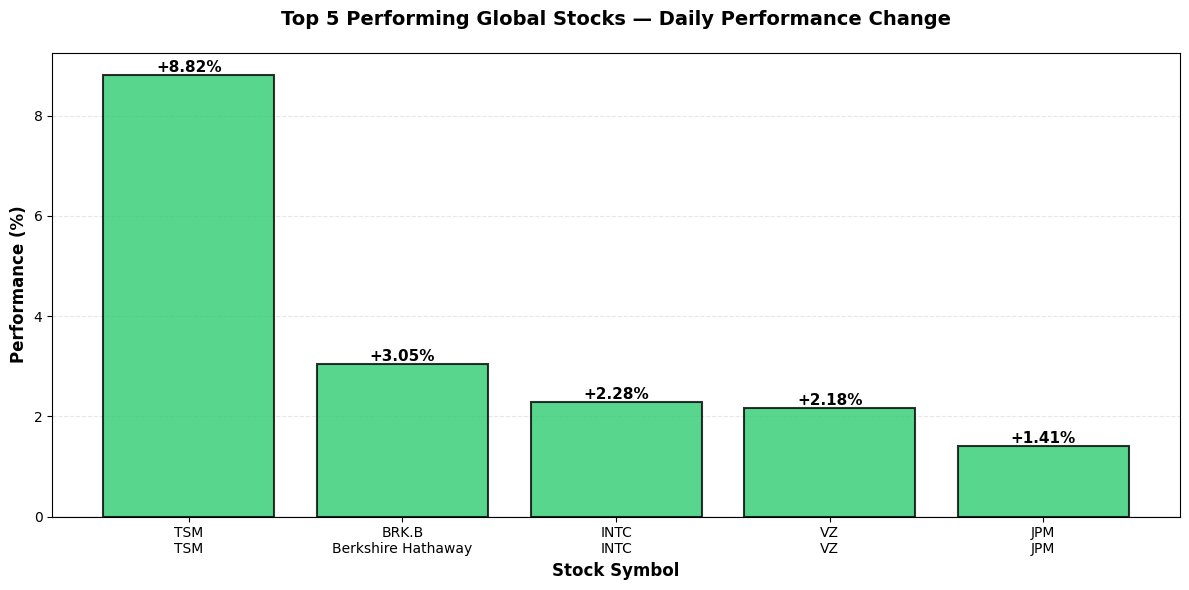

✓ Successfully created performance chart for 5 stocks


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ===== PERFORMANCE BAR CHART =====
print("Creating performance bar chart for top 5 stocks...")

if top5_performance and len(top5_performance) > 0:
    symbols_list = [sym for sym, _ in top5_performance]
    performance_list = [pct for _, pct in top5_performance]
    company_names = [get_company_name(sym) for sym in symbols_list]
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Color bars based on positive/negative performance
    colors = ['#2ecc71' if pct > 0 else '#e74c3c' for pct in performance_list]
    bars = ax.bar(range(len(symbols_list)), performance_list, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Customize the chart
    ax.set_xlabel('Stock Symbol', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance (%)', fontsize=12, fontweight='bold')
    ax.set_title('Top 5 Performing Global Stocks — Daily Performance Change', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(range(len(symbols_list)))
    ax.set_xticklabels([f"{sym}\n{name}" for sym, name in zip(symbols_list, company_names)], fontsize=10)
    
    # Add a horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Add value labels on bars
    for i, (bar, pct) in enumerate(zip(bars, performance_list)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:+.2f}%',
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=11, fontweight='bold')
    
    # Grid and styling
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    print(f"✓ Successfully created performance chart for {len(symbols_list)} stocks")
else:
    print("⚠ No performance data available. Please run Cell 1 first.")


### This is for "FAVORITED" stocks for tracking - Stocks Watchlist
- AMZN, MSFT, GOOGL, NVDA, META

In [4]:
# ===== ANALYSIS 2: USER WATCHLIST =====
import time
import pandas as pd
import numpy as np
from datetime import datetime

print("\n" + "=" * 70)
print("ANALYSIS 2: WATCHLIST MONITORING")
print("=" * 70)

# Define watchlist
WATCHLIST = ["AAPL", "NVDA", "MSFT", "META", "GOOGL"]


def fetch_price_history_local(sym: str, period: str = "2d") -> pd.DataFrame:
    """Fetch price history - uses mock data."""
    days = 2 if "2d" in period else 7
    base_price = (abs(hash(sym)) % 400) + 50
    np.random.seed(abs(hash(sym)) % 2**31)
    dates = pd.date_range(end=datetime.now().date(), periods=days, freq='B')
    closes = base_price + np.cumsum(np.random.randn(days) * 2)
    closes = np.clip(closes, 1, None)
    df = pd.DataFrame({
        "Open":  closes + np.random.uniform(-1, 1, days),
        "High":  closes + np.abs(np.random.randn(days) * 1.5),
        "Low":   closes - np.abs(np.random.randn(days) * 1.5),
        "Close": closes,
    }, index=dates)
    return df.clip(lower=0.01)


def monitor_watchlist(symbols: list[str], delay: float = 0.5) -> list[tuple]:
    """Monitor watchlist for daily performance. Returns list of (symbol, pct_change) tuples."""
    performance = []
    for i, sym in enumerate(symbols):
        try:
            print(f"[{i+1}/{len(symbols)}] Monitoring {sym}...", end="", flush=True)
            hist = fetch_price_history_local(sym, period="2d")
            
            if hist.empty or len(hist) < 2:
                print(" (insufficient data)")
                continue
            
            prev_close = hist["Close"].iloc[-2]
            last_close = hist["Close"].iloc[-1]
            pct = (last_close - prev_close) / prev_close * 100
            performance.append((sym, pct))
            print(f" ✓ {pct:+.2f}%")
        except Exception as e:
            print(f" ✗ {str(e)[:30]}")
        time.sleep(delay)
    
    performance.sort(key=lambda x: x[1], reverse=True)
    return performance


# Run watchlist analysis
print("\nAnalyzing watchlist performance...")
results = monitor_watchlist(WATCHLIST, delay=0.1)

# Display watchlist performance
if results:
    print("\nWatchlist Performance (sorted by % change):")
    for sym, pct in results:
        company_name = get_company_name(sym)
        print(f"  {sym:6} - {company_name:25} {pct:+.2f}%")
else:
    print("⚠ No watchlist performance data available.")

# Fetch OHLC data for watchlist
print("\nFetching 7-Day OHLC for watchlist...")
watchlist_ohlc_data = fetch_ohlc_data(WATCHLIST, period="7d", delay=0.1)

# Display detailed price data
if watchlist_ohlc_data:
    print(f"\n{'='*70}")
    print("Watchlist - 7-Day Price Data")
    print(f"{'='*70}")
    for sym in WATCHLIST:
        if sym in watchlist_ohlc_data:
            df = watchlist_ohlc_data[sym]
            company_name = get_company_name(sym)
            
            if not df.empty:
                print(f"\n{sym} - {company_name} (last {len(df)} days):")
                df_display = df.copy()
                for col in ["Open", "High", "Low", "Close"]:
                    df_display[col] = df_display[col].apply(lambda x: f"${x:.2f}")
                print(df_display)
            else:
                print(f"\n{sym} - {company_name}: No data available")
else:
    print("⚠ No OHLC data was fetched for watchlist.")



ANALYSIS 2: WATCHLIST MONITORING

Analyzing watchlist performance...
[1/5] Monitoring AAPL... ✓ -0.40%
[2/5] Monitoring NVDA... ✓ +1.01%
[3/5] Monitoring MSFT... ✓ +0.46%
[4/5] Monitoring META... ✓ -2.02%
[5/5] Monitoring GOOGL... ✓ -1.83%

Watchlist Performance (sorted by % change):
  NVDA   - NVIDIA Corporation        +1.01%
  MSFT   - Microsoft Corporation     +0.46%
  AAPL   - Apple Inc.                -0.40%
  GOOGL  - Alphabet Inc.             -1.83%
  META   - Meta Platforms            -2.02%

Fetching 7-Day OHLC for watchlist...
  [1/5] OHLC AAPL  ✓  (7 days)
  [2/5] OHLC NVDA  ✓  (7 days)
  [3/5] OHLC MSFT  ✓  (7 days)
  [4/5] OHLC META  ✓  (7 days)
  [5/5] OHLC GOOGL  ✓  (7 days)

Watchlist - 7-Day Price Data

AAPL - Apple Inc. (last 7 days):
               Open     High      Low    Close
2026-04-21  $414.42  $414.50  $412.14  $414.00
2026-04-22  $411.97  $413.74  $411.88  $412.33
2026-04-23  $412.71  $413.07  $411.58  $412.97
2026-04-24  $412.73  $413.64  $411.28  $412.79
2

Creating visualization for watchlist...


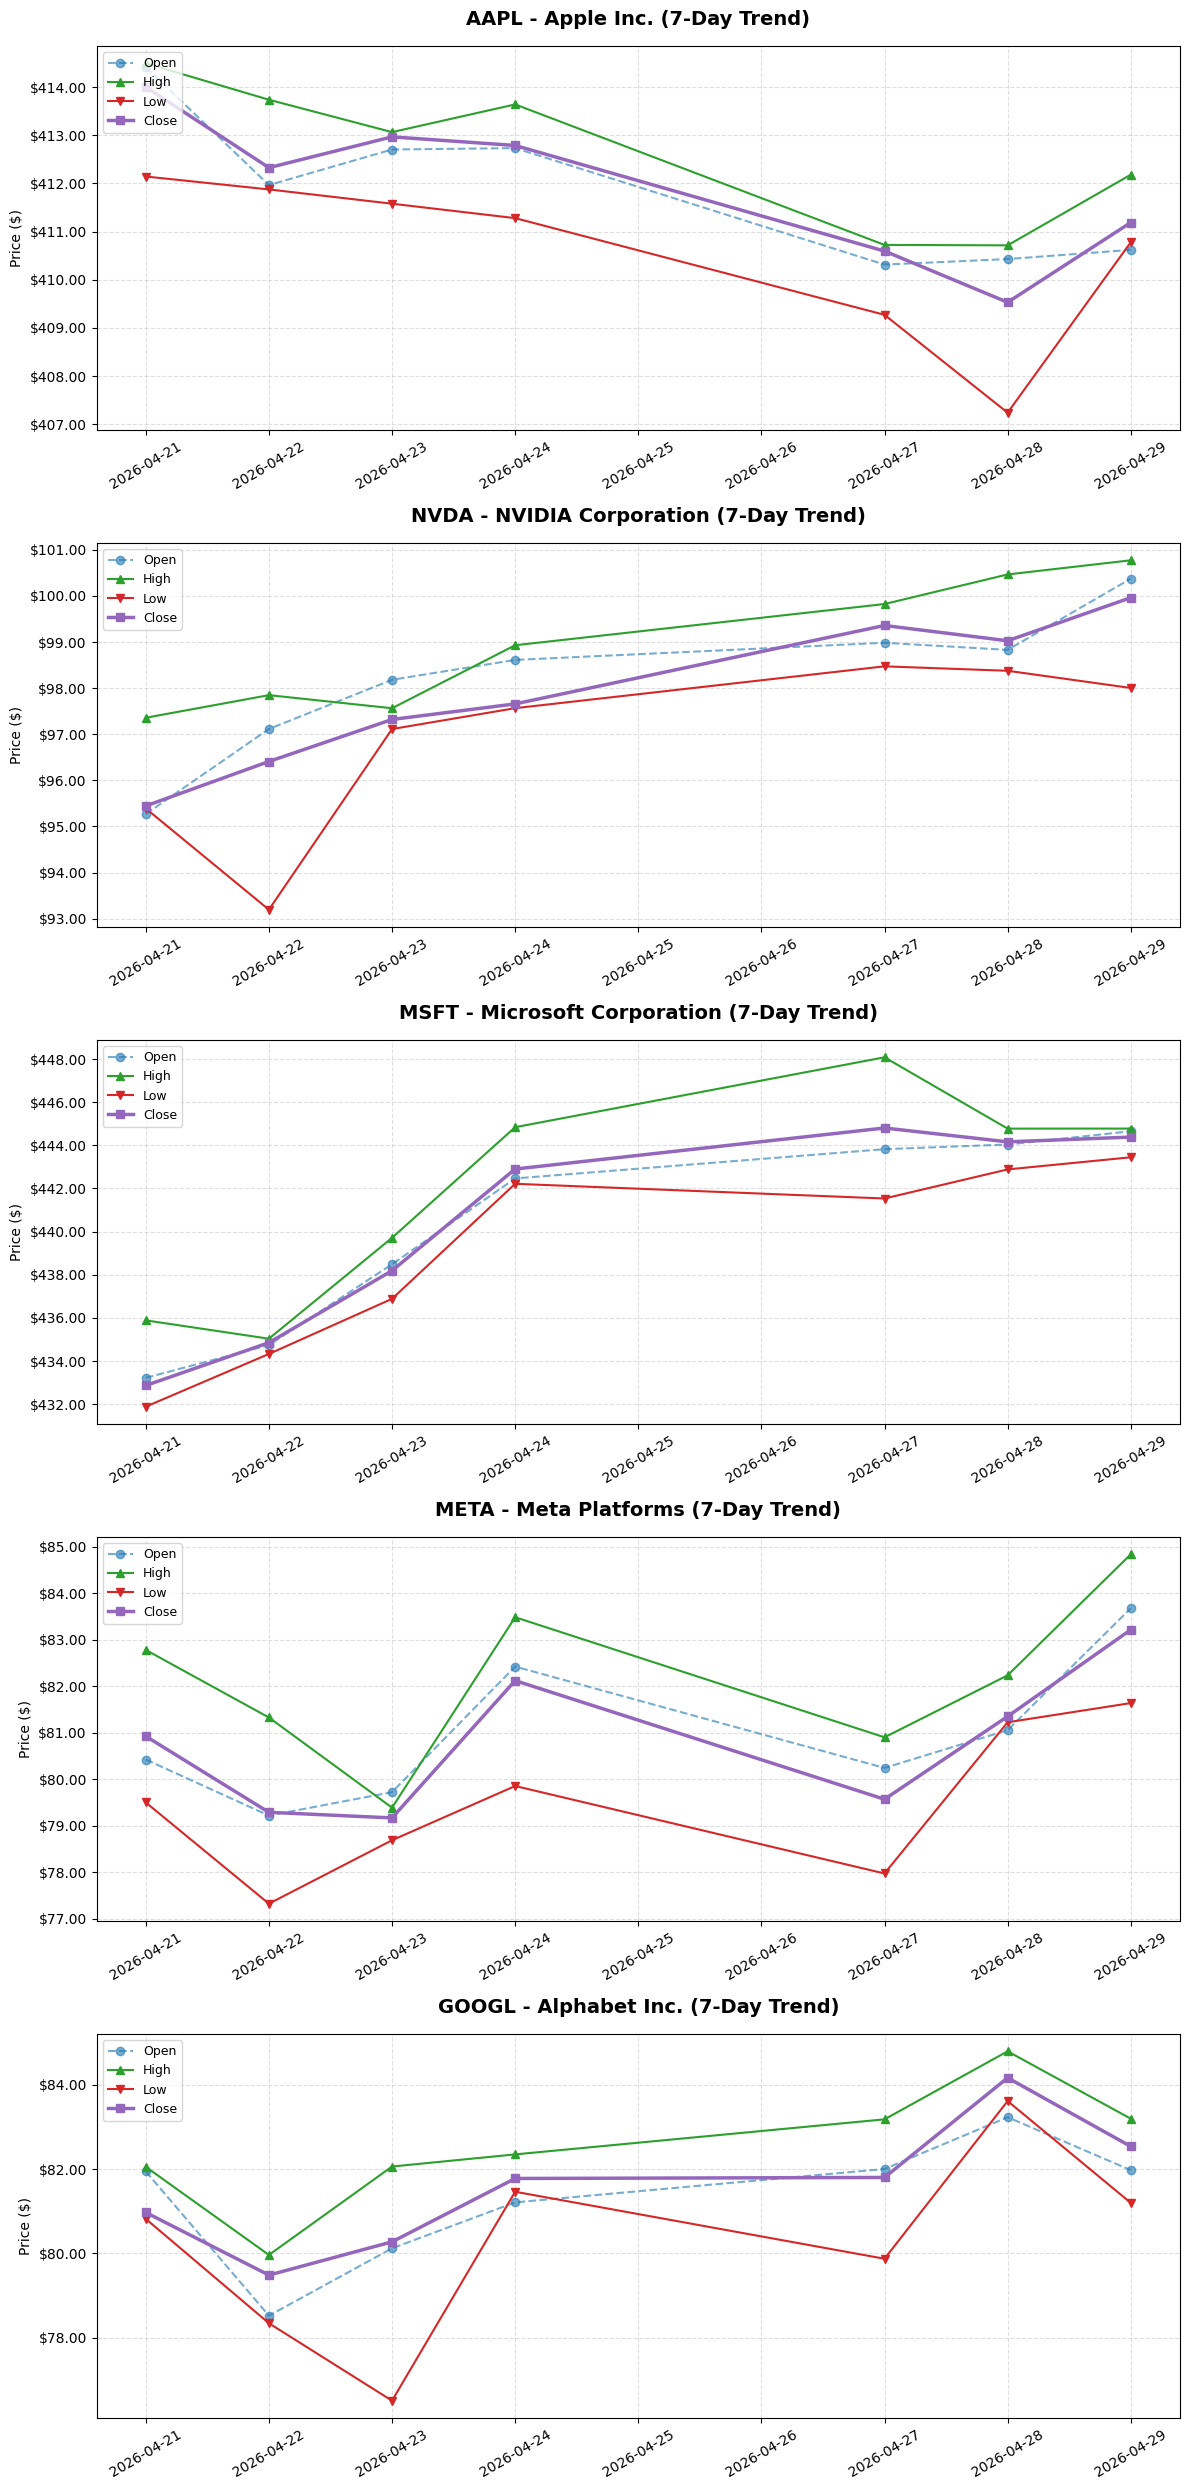

✓ Successfully plotted 5 stocks from watchlist


In [5]:
# ===== PLOT WATCHLIST DATA =====
print("Creating visualization for watchlist...")

n = len(watchlist_ohlc_data)

if n == 0:
    print("ERROR: No data available to plot. Please run Cell 4 first.")
else:
    fig, axs = plt.subplots(n, 1, figsize=(12, 5 * n), sharex=False)

    # Ensure axs is always an iterable list
    if n == 1:
        axs = [axs]

    for ax, (sym, df) in zip(axs, watchlist_ohlc_data.items()):
        company_name = get_company_name(sym)
        
        # Only plot if data is available
        if df.empty or len(df) < 2:
            ax.text(0.5, 0.5, f"No data for {sym}", ha='center', va='center', fontsize=14)
            ax.set_title(f"{sym} - {company_name} (No Data)")
            continue
        
        # Plot the four OHLC components
        ax.plot(df.index, df["Open"], marker="o", label="Open", color="tab:blue", linestyle="--", alpha=0.6)
        ax.plot(df.index, df["High"], marker="^", label="High", color="tab:green", linewidth=1.5)
        ax.plot(df.index, df["Low"], marker="v", label="Low", color="tab:red", linewidth=1.5)
        ax.plot(df.index, df["Close"], marker="s", label="Close", color="tab:purple", linewidth=2.5)

        # Title and Labels
        ax.set_title(f"{sym} - {company_name} (7-Day Trend)", fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel("Price ($)")
        
        # Formatting
        ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="upper left", fontsize=9) 
        
        # Format the X-axis dates
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    print(f"✓ Successfully plotted {n} stocks from watchlist")
